# Reconocimiento de Emociones Faciales
### Modelo de Deep Learning con EfficientNetB0 + FER2013

**Emociones detectadas:** Desesperanza · Orgullo · Confusión · Neutralidad · Felicidad

---
**Pipeline:**
1. Instalación y carga de dependencias
2. Descarga del dataset FER2013
3. Preprocesamiento y denoising de imágenes
4. Construcción del modelo (EfficientNetB0 + fine-tuning)
5. Entrenamiento con data augmentation
6. Evaluación y visualizaciones
7. Inferencia: sube tu propia foto

>  **Recomendado:** Activar GPU en Colab → Menú `Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU T4`

## Instalación de Dependencias

In [7]:
# Instalar dependencias necesarias
!pip install -q kaggle opencv-python-headless mediapipe tensorflow matplotlib seaborn scikit-learn Pillow tqdm
print(' Dependencias instaladas correctamente')

 Dependencias instaladas correctamente


## Importaciones y Configuración Global

In [8]:
import os, sys, warnings, random, zipfile, shutil
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageFilter
from IPython.display import display, HTML, clear_output
from google.colab import files, drive

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────
# CONFIGURACIÓN GLOBAL
# ──────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE    = 96          # EfficientNetB0 acepta 96-600px; 96 es rápido y efectivo
BATCH_SIZE  = 64
EPOCHS_HEAD = 15          # Entrenamiento solo de la cabeza
EPOCHS_FT   = 20          # Fine-tuning de las últimas capas
LR_HEAD     = 1e-3
LR_FT       = 5e-5
DATA_DIR    = Path('/content/fer_data')
MODEL_PATH  = '/content/emotion_model_best.h5'

# Mapeo: FER2013 tiene 7 clases → nuestras 5 emociones
# FER labels: 0=Angry,1=Disgust,2=Fear,3=Happy,4=Sad,5=Surprise,6=Neutral
FER_TO_CUSTOM = {
    0: 'desesperanza',   # Angry  → desesperanza
    1: 'desesperanza',   # Disgust → desesperanza
    2: 'confusion',      # Fear   → confusión
    3: 'felicidad',      # Happy  → felicidad
    4: 'desesperanza',   # Sad    → desesperanza
    5: 'orgullo',        # Surprise → orgullo
    6: 'neutralidad',    # Neutral  → neutralidad
}

EMOTION_LABELS = ['confusion', 'desesperanza', 'felicidad', 'neutralidad', 'orgullo']
EMOTION_COLORS = {
    'confusion':     '#F4A261',
    'desesperanza':  '#457B9D',
    'felicidad':     '#2DC653',
    'neutralidad':   '#A8DADC',
    'orgullo':       '#E63946',
}

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f' GPU disponible: {gpus[0].name}')
else:
    print(' No se detectó GPU. El entrenamiento será más lento en CPU.')

print(f' TensorFlow: {tf.__version__}')
print(f' Configuración cargada — IMG_SIZE={IMG_SIZE}, BATCH={BATCH_SIZE}')

 GPU disponible: /physical_device:GPU:0
 TensorFlow: 2.20.0
 Configuración cargada — IMG_SIZE=96, BATCH=64


## Carga del Dataset FER2013

> **FER2013** es el dataset estándar para reconocimiento facial de emociones.  
> ~35,000 imágenes de 48×48 px, etiquetadas con 7 emociones. Licencia: libre para investigación.


In [9]:
import zipfile, os
from google.colab import files

RAW_DIR = '/content/fer_raw'
os.makedirs(RAW_DIR, exist_ok=True)

# ── Subir el ZIP desde tu PC ────────────────────────────────
print(' Selecciona el archivo ZIP de FER2013 (archive.zip):')
uploaded = files.upload()

if not uploaded:
    raise RuntimeError(' No se subió ningún archivo. Vuelve a ejecutar esta celda.')

zip_filename = list(uploaded.keys())[0]
zip_path = f'/content/{zip_filename}'

# Guardar el ZIP en disco (files.upload() ya lo hace, confirmamos)
with open(zip_path, 'wb') as f:
    f.write(uploaded[zip_filename])

print(f' Archivo recibido: {zip_filename} ({os.path.getsize(zip_path)/1024/1024:.1f} MB)')

# ── Verificar que sea un ZIP válido ────────────────────────
if not zipfile.is_zipfile(zip_path):
    raise ValueError(' El archivo no es un ZIP válido. Verifica que descargaste el archivo correcto.')

# ── Extraer contenido ──────────────────────────────────────
print(f' Extrayendo en {RAW_DIR}...')
with zipfile.ZipFile(zip_path, 'r') as zf:
    members = zf.namelist()
    print(f'   Archivos en el ZIP: {len(members)}')
    zf.extractall(RAW_DIR)

# ── Detectar estructura interna del ZIP ───────────────────
# FER2013 de Kaggle puede venir con distintas estructuras:
# Opción A: fer_raw/train/happy/... fer_raw/test/happy/...
# Opción B: fer_raw/archive/train/happy/... (carpeta intermedia)
# Opción C: fer_raw/fer2013/train/...

def find_split_dir(base: str, split: str):
    """Busca recursivamente la carpeta 'train' o 'test' dentro de base."""
    for root, dirs, _ in os.walk(base):
        if split in dirs:
            return os.path.join(root, split)
    return None

train_dir = find_split_dir(RAW_DIR, 'train')
test_dir  = find_split_dir(RAW_DIR, 'test')

if train_dir and test_dir:
    # Normalizar: mover todo a /content/fer_raw/train y /content/fer_raw/test
    import shutil
    for split, src in [('train', train_dir), ('test', test_dir)]:
        dest = os.path.join(RAW_DIR, split)
        if os.path.abspath(src) != os.path.abspath(dest):
            if os.path.exists(dest):
                shutil.rmtree(dest)
            shutil.copytree(src, dest)
    print(f' Estructura normalizada correctamente')
else:
    raise FileNotFoundError(
        ' No se encontraron las carpetas train/test dentro del ZIP.\n'
        f'   Contenido detectado en {RAW_DIR}:\n   ' +
        '\n   '.join(os.listdir(RAW_DIR))
    )

# ── Resumen del dataset extraído ──────────────────────────
print('\n Dataset extraído — conteo por clase:')
fer_emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
for split in ['train', 'test']:
    split_path = os.path.join(RAW_DIR, split)
    print(f'  [{split}]')
    total = 0
    for emo in sorted(os.listdir(split_path)):
        emo_path = os.path.join(split_path, emo)
        if os.path.isdir(emo_path):
            n = len(os.listdir(emo_path))
            total += n
            print(f'    {emo:10s}: {n:5d} imágenes')
    print(f'    {"TOTAL":10s}: {total:5d} imágenes')

# Liberar memoria del ZIP en RAM
del uploaded
os.remove(zip_path)
print(f'\n  ZIP eliminado para liberar espacio.')
print(' Dataset listo para preprocesar.')

 Selecciona el archivo ZIP de FER2013 (archive.zip):


Saving archive.zip to archive.zip
 Archivo recibido: archive.zip (60.3 MB)
 Extrayendo en /content/fer_raw...
   Archivos en el ZIP: 35887
 Estructura normalizada correctamente

 Dataset extraído — conteo por clase:
  [train]
    angry     :  3995 imágenes
    disgust   :   436 imágenes
    fear      :  4097 imágenes
    happy     :  7215 imágenes
    neutral   :  4965 imágenes
    sad       :  4830 imágenes
    surprise  :  3171 imágenes
    TOTAL     : 28709 imágenes
  [test]
    angry     :   958 imágenes
    disgust   :   111 imágenes
    fear      :  1024 imágenes
    happy     :  1774 imágenes
    neutral   :  1233 imágenes
    sad       :  1247 imágenes
    surprise  :   831 imágenes
    TOTAL     :  7178 imágenes

  ZIP eliminado para liberar espacio.
 Dataset listo para preprocesar.


## Preprocesamiento del Dataset

Pasos por imagen:
1. **Detección facial** con Haar Cascade (rápido) o recorte centrado si no detecta rostro
2. **Denoising** con filtro bilateral (preserva bordes mientras elimina ruido)
3. **CLAHE** — mejora contraste adaptativo (útil en imágenes con iluminación irregular)
4. **Remapeo de etiquetas** FER (7 clases) → nuestras 5 emociones
5. Guardado en estructura de carpetas por emoción

In [10]:
# Cargar el clasificador de rostros de OpenCV
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def preprocess_face(img_gray: np.ndarray, target_size: int = IMG_SIZE) -> np.ndarray:
    """
    Pipeline de preprocesamiento robusto para una imagen de rostro.
    Entrada:  imagen en escala de grises (numpy array)
    Salida:   imagen RGB normalizada de shape (target_size, target_size, 3)
    """
    # 1. Detección de rostro
    faces = face_cascade.detectMultiScale(
        img_gray, scaleFactor=1.1, minNeighbors=4, minSize=(20, 20)
    )
    if len(faces) > 0:
        x, y, w, h = sorted(faces, key=lambda f: f[2]*f[3], reverse=True)[0]
        margin = int(0.15 * min(w, h))
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(img_gray.shape[1], x + w + margin)
        y2 = min(img_gray.shape[0], y + h + margin)
        img_gray = img_gray[y1:y2, x1:x2]

    # 2. Denoising bilateral — elimina ruido preservando bordes
    img_denoised = cv2.bilateralFilter(img_gray, d=9, sigmaColor=75, sigmaSpace=75)

    # 3. CLAHE — mejora de contraste adaptativo
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    img_enhanced = clahe.apply(img_denoised)

    # 4. Redimensionar al tamaño objetivo
    img_resized = cv2.resize(img_enhanced, (target_size, target_size),
                             interpolation=cv2.INTER_LANCZOS4)

    # 5. Convertir a RGB (EfficientNet espera 3 canales)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)

    return img_rgb  # uint8 [0, 255]


def build_dataset(raw_dir: str, out_dir: Path, split: str):
    """
    Procesa todas las imágenes de un split (train/test),
    remapea etiquetas y las guarda organizadas por emoción.
    """
    raw_path = Path(raw_dir) / split
    fer_labels = sorted(os.listdir(raw_path))  # carpetas numéricas o por nombre

    # FER2013 de Kaggle tiene carpetas por nombre de emoción en inglés
    fer_name_to_id = {
        'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3,
        'sad': 4, 'surprise': 5, 'neutral': 6
    }

    split_out = out_dir / split
    for emo in EMOTION_LABELS:
        (split_out / emo).mkdir(parents=True, exist_ok=True)

    processed, skipped = 0, 0
    for folder in tqdm(fer_labels, desc=f'Procesando {split}'):
        folder_lower = folder.lower()
        if folder_lower not in fer_name_to_id:
            continue
        fer_id = fer_name_to_id[folder_lower]
        target_emotion = FER_TO_CUSTOM[fer_id]

        src_folder = raw_path / folder
        for img_file in src_folder.iterdir():
            if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            try:
                img_gray = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)
                if img_gray is None:
                    skipped += 1
                    continue
                img_processed = preprocess_face(img_gray)
                out_path = split_out / target_emotion / img_file.name
                cv2.imwrite(str(out_path), cv2.cvtColor(img_processed, cv2.COLOR_RGB2BGR))
                processed += 1
            except Exception as e:
                skipped += 1

    print(f'   {split}: {processed} imágenes procesadas, {skipped} omitidas')


# Ejecutar preprocesamiento
DATA_DIR.mkdir(parents=True, exist_ok=True)
build_dataset('/content/fer_raw', DATA_DIR, 'train')
build_dataset('/content/fer_raw', DATA_DIR, 'test')

print('\n Distribución del dataset procesado:')
for split in ['train', 'test']:
    print(f'  [{split}]')
    for emo in EMOTION_LABELS:
        count = len(list((DATA_DIR / split / emo).glob('*.png'))) + \
                len(list((DATA_DIR / split / emo).glob('*.jpg')))
        print(f'    {emo:15s}: {count:5d} imgs')

Procesando train: 100%|██████████| 7/7 [01:05<00:00,  9.32s/it]


   train: 28709 imágenes procesadas, 0 omitidas


Procesando test: 100%|██████████| 7/7 [00:14<00:00,  2.08s/it]


   test: 7178 imágenes procesadas, 0 omitidas

 Distribución del dataset procesado:
  [train]
    confusion      :  4097 imgs
    desesperanza   :  9261 imgs
    felicidad      :  7215 imgs
    neutralidad    :  4965 imgs
    orgullo        :  3171 imgs
  [test]
    confusion      :  1024 imgs
    desesperanza   :  2316 imgs
    felicidad      :  1774 imgs
    neutralidad    :  1233 imgs
    orgullo        :   831 imgs


## Visualización del Dataset

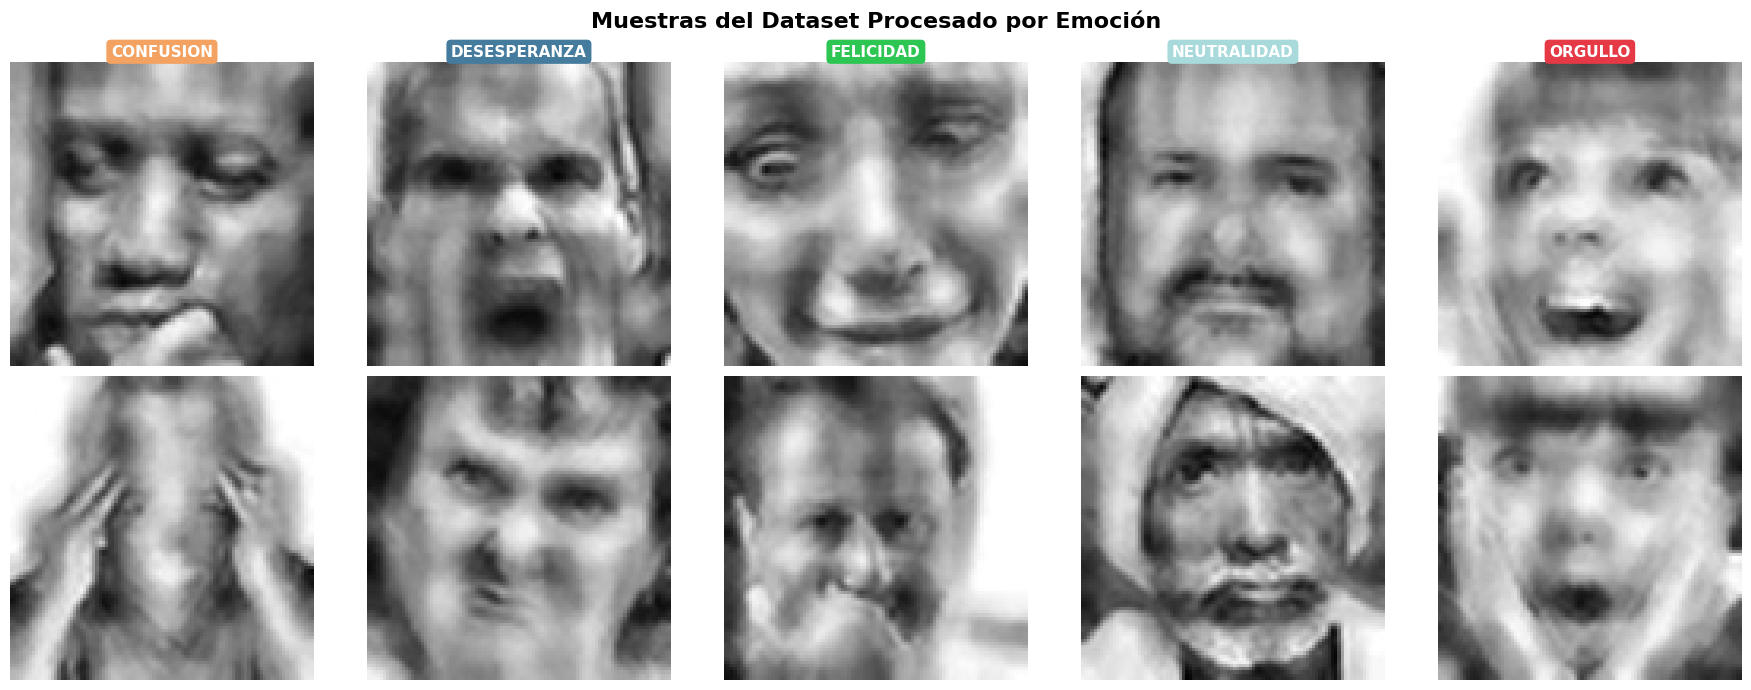

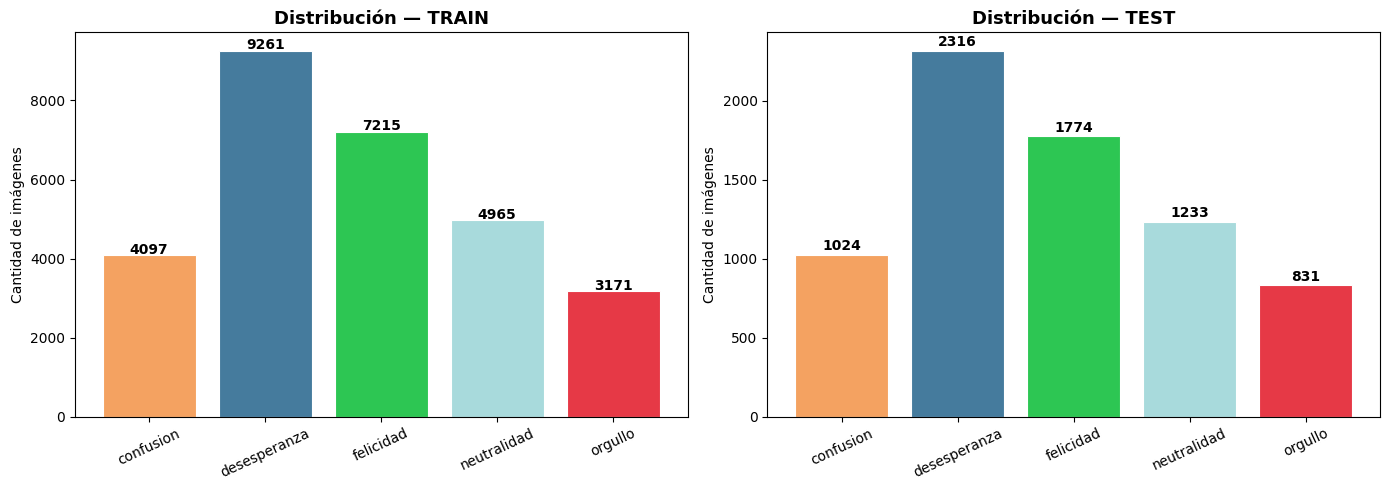

In [11]:
fig, axes = plt.subplots(2, len(EMOTION_LABELS), figsize=(18, 7))
fig.suptitle('Muestras del Dataset Procesado por Emoción', fontsize=16, fontweight='bold')

for col, emo in enumerate(EMOTION_LABELS):
    imgs = list((DATA_DIR / 'train' / emo).glob('*.png'))[:2] + \
           list((DATA_DIR / 'train' / emo).glob('*.jpg'))[:2]
    for row in range(2):
        ax = axes[row][col]
        if row < len(imgs):
            img = cv2.imread(str(imgs[row]))
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis('off')
        if row == 0:
            color = EMOTION_COLORS[emo]
            ax.set_title(emo.upper(), fontsize=11, fontweight='bold',
                         color='white', pad=4,
                         bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.savefig('/content/dataset_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# Gráfico de distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for idx, split in enumerate(['train', 'test']):
    counts = {}
    for emo in EMOTION_LABELS:
        n = len(list((DATA_DIR / split / emo).glob('*.png'))) + \
            len(list((DATA_DIR / split / emo).glob('*.jpg')))
        counts[emo] = n
    colors = [EMOTION_COLORS[e] for e in counts.keys()]
    bars = axes[idx].bar(counts.keys(), counts.values(), color=colors, edgecolor='white', linewidth=0.8)
    axes[idx].set_title(f'Distribución — {split.upper()}', fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Cantidad de imágenes')
    axes[idx].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, counts.values()):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                       str(val), ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/dataset_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Construcción del Modelo

Arquitectura:
- **Base:** EfficientNetB0 preentrenado en ImageNet (sin la capa de clasificación)
- **Cabeza:** GlobalAveragePooling → BatchNorm → Dropout → Dense(256) → Dropout → Softmax(5)
- **Estrategia:** Primero entrenar solo la cabeza (base congelada), luego fine-tuning de las últimas capas

In [12]:
def build_model(num_classes: int = 5, img_size: int = IMG_SIZE) -> Model:
    """Construye el modelo EfficientNetB0 con cabeza de clasificación personalizada."""
    inputs = layers.Input(shape=(img_size, img_size, 3), name='input_image')

    # Preprocesamiento integrado en el modelo
    x = layers.Rescaling(1./255)(inputs)  # normalizar a [0, 1]

    # Base EfficientNetB0 — congelada inicialmente
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=x,
        pooling=None,
    )
    base.trainable = False  # Se descongelará en fase de fine-tuning

    # Cabeza de clasificación
    x = base.output
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_256'
    )(x)
    x = layers.BatchNormalization(name='bn_dense')(x)
    x = layers.Dropout(0.3, name='drop2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs=inputs, outputs=outputs, name='EmotionNet')
    return model


model = build_model()
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_HEAD),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Resumen del modelo
trainable = sum(np.prod(v.shape) for v in model.trainable_weights)
total     = sum(np.prod(v.shape) for v in model.weights)
print(model.summary())
print(f'\n Parámetros totales:     {total:,}')
print(f' Parámetros entrenables: {trainable:,}')

Model: "EmotionNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input_image[0][0] │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 96, 96, 3) │          0 │ rescaling[0][0]   │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 96, 96, 3) │          7 │ rescaling_1[0][0] │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 96, 96, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 97, 97, 3) │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 48, 48,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 48, 48,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 48, 48,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 48, 48,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 48, 48,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 48, 48,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 48, 48,    │          0 │ block1a_activati

 Total params: 4,384,936 (16.73 MB)

 Trainable params: 332,293 (1.27 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

None

 Parámetros totales:     4,384,936.0
 Parámetros entrenables: 332,293


## Data Augmentation y Generadores

Found 28709 images belonging to 5 classes.
Found 7178 images belonging to 5 classes.

📦 Clases → índices: {'confusion': 0, 'desesperanza': 1, 'felicidad': 2, 'neutralidad': 3, 'orgullo': 4}
  Pesos de clase (para balance): {0: np.float64(1.4014644862094214), 1: np.float64(0.6199978404060037), 2: np.float64(0.7958142758142758), 3: np.float64(1.1564551863041288), 4: np.float64(1.810722169662567)}


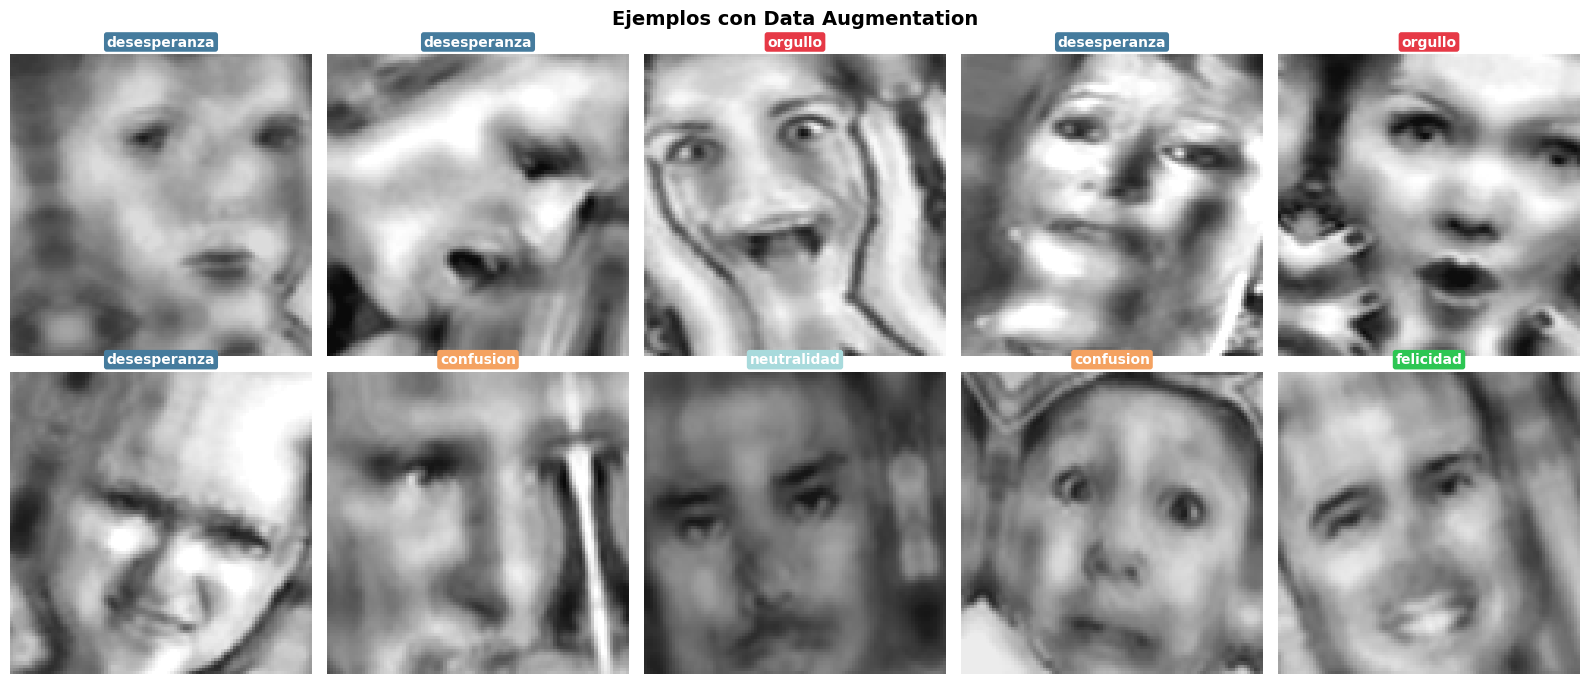

In [13]:
# ── Augmentation solo para TRAIN ─────────────────────────────────
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.75, 1.25],
    channel_shift_range=20.0,
    fill_mode='reflect',
)

val_datagen = ImageDataGenerator()  # sin augmentation para evaluación

train_gen = train_datagen.flow_from_directory(
    str(DATA_DIR / 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    shuffle=True,
    seed=SEED,
)

test_gen = val_datagen.flow_from_directory(
    str(DATA_DIR / 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=EMOTION_LABELS,
    shuffle=False,
)

print(f'\n📦 Clases → índices: {train_gen.class_indices}')

# Calcular pesos de clase para manejar desbalance
y_train = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))
print(f'  Pesos de clase (para balance): {class_weights}')

# Visualizar augmentación
sample_imgs, sample_labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Ejemplos con Data Augmentation', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    if i < len(sample_imgs):
        ax.imshow(sample_imgs[i].astype('uint8'))
        label_idx = np.argmax(sample_labels[i])
        emo = EMOTION_LABELS[label_idx]
        ax.set_title(emo, fontsize=10,
                     color='white', fontweight='bold',
                     bbox=dict(facecolor=EMOTION_COLORS[emo], edgecolor='none',
                               boxstyle='round,pad=0.2'))
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/augmentation_samples.png', dpi=110, bbox_inches='tight')
plt.show()

## Fase 1: Entrenamiento de la Cabeza

In [14]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('  FASE 1: Entrenando cabeza de clasificación (base congelada)...')
print(f'   Épocas máximas: {EPOCHS_HEAD} | LR: {LR_HEAD}')
print('─' * 60)

history1 = model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=test_gen,
    callbacks=callbacks_phase1,
    class_weight=class_weights,
    verbose=1,
)
print(' Fase 1 completada')

  FASE 1: Entrenando cabeza de clasificación (base congelada)...
   Épocas máximas: 15 | LR: 0.001
────────────────────────────────────────────────────────────
Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.1989 - auc: 0.5050 - loss: 2.0434
Epoch 1: val_accuracy improved from None to 0.24868, saving model to /content/emotion_model_best.h5



Epoch 1: finished saving model to /content/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 181s 334ms/step - accuracy: 0.2025 - auc: 0.5070 - loss: 1.9049 - val_accuracy: 0.2487 - val_auc: 0.4935 - val_loss: 1.6828 - learning_rate: 0.0010
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.1971 - auc: 0.4997 - loss: 1.7677
Epoch 2: val_accuracy did not improve from 0.24868
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 248ms/step - accuracy: 0.1953 - auc: 0.5002 - loss: 1.7437 - val_accuracy: 0.1427 - val_auc: 0.3994 - val_loss: 1.7085 - learning_rate: 0.0010
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1943 - auc: 0.5008 - loss: 1.7004
Epoch 3: val_accuracy did not improve from 0.24868
449/449 ━━━━━━━━━━━━━━━━━━━━ 110s 245ms/step - accuracy: 0.1959 - auc: 0.5027 - loss: 1.6904 - val_accuracy: 0.1158 - val_auc: 0.4454 - val_loss: 1.6633 - learning_rate: 0.0010
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1963 - auc: 0.5079 - loss: 1.

## 🔓 Celda 9 — Fase 2: Fine-Tuning de Capas Profundas

In [15]:
import keras

# Identify the start and end indices of the EfficientNetB0 core layers
# The EfficientNetB0 core typically starts with 'stem_conv_pad' and ends before the 'gap' (GlobalAveragePooling2D) layer.
start_efficientnet_idx = -1
end_efficientnet_idx = -1

for i, layer in enumerate(model.layers):
    if layer.name == 'stem_conv_pad':  # Typical start of EfficientNetB0 core
        start_efficientnet_idx = i
    if layer.name == 'gap':  # Start of custom head, so EfficientNetB0 ends before this
        end_efficientnet_idx = i
        break

if start_efficientnet_idx == -1 or end_efficientnet_idx == -1:
    print("Could not identify EfficientNetB0 core layers. Please check model summary for layer names.")
    # Fallback or raise an error, depending on desired robustness
    # For now, let's assume the issue is fatal if layers aren't found
    raise ValueError("Could not identify EfficientNetB0 core layers within the model.")

efficientnet_core_layers = model.layers[start_efficientnet_idx:end_efficientnet_idx]

# First, make all EfficientNetB0 core layers trainable
for layer in efficientnet_core_layers:
    layer.trainable = True

# Then, freeze all but the last 30 layers of the EfficientNetB0 part
num_efficientnet_core_layers = len(efficientnet_core_layers)
if num_efficientnet_core_layers > 30:
    for layer in efficientnet_core_layers[:-30]:
        layer.trainable = False
else:
    print(f"Warning: EfficientNetB0 core has only {num_efficientnet_core_layers} layers, all will be trainable.")

unfrozen = sum(1 for l in efficientnet_core_layers if l.trainable)
print(f' Capas descongeladas en la base del modelo (EfficientNetB0): {unfrozen}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FT),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('\n FASE 2: Fine-tuning de capas profundas...')
print(f'   Épocas máximas: {EPOCHS_FT} | LR: {LR_FT}')
print('─' * 60)

history2 = model.fit(
    train_gen,
    epochs=EPOCHS_FT,
    validation_data=test_gen,
    callbacks=callbacks_phase2,
    class_weight=class_weights,
    verbose=1,
)
print('Fine-tuning completado')

 Capas descongeladas en la base del modelo (EfficientNetB0): 30

 FASE 2: Fine-tuning de capas profundas...
   Épocas máximas: 20 | LR: 5e-05
────────────────────────────────────────────────────────────
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.2055 - auc: 0.5054 - loss: 1.8608
Epoch 1: val_accuracy improved from None to 0.24714, saving model to /content/emotion_model_best.h5



Epoch 1: finished saving model to /content/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 180s 324ms/step - accuracy: 0.2039 - auc: 0.5074 - loss: 1.8276 - val_accuracy: 0.2471 - val_auc: 0.6131 - val_loss: 1.6089 - learning_rate: 5.0000e-05
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.1989 - auc: 0.4984 - loss: 1.8068
Epoch 2: val_accuracy did not improve from 0.24714
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 248ms/step - accuracy: 0.2003 - auc: 0.5024 - loss: 1.7881 - val_accuracy: 0.2409 - val_auc: 0.5730 - val_loss: 1.6372 - learning_rate: 5.0000e-05
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.2017 - auc: 0.5046 - loss: 1.7642
Epoch 3: val_accuracy improved from 0.24714 to 0.25704, saving model to /content/emotion_model_best.h5



Epoch 3: finished saving model to /content/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 250ms/step - accuracy: 0.1997 - auc: 0.5045 - loss: 1.7665 - val_accuracy: 0.2570 - val_auc: 0.6190 - val_loss: 1.6132 - learning_rate: 5.0000e-05
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.1955 - auc: 0.5006 - loss: 1.7656
Epoch 4: val_accuracy improved from 0.25704 to 0.32265, saving model to /content/emotion_model_best.h5



Epoch 4: finished saving model to /content/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.2003 - auc: 0.5036 - loss: 1.7548 - val_accuracy: 0.3227 - val_auc: 0.6375 - val_loss: 1.6099 - learning_rate: 5.0000e-05
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.1960 - auc: 0.5000 - loss: 1.7530
Epoch 5: val_accuracy did not improve from 0.32265
449/449 ━━━━━━━━━━━━━━━━━━━━ 110s 245ms/step - accuracy: 0.1974 - auc: 0.5030 - loss: 1.7449 - val_accuracy: 0.3227 - val_auc: 0.6458 - val_loss: 1.5971 - learning_rate: 5.0000e-05
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.1982 - auc: 0.5061 - loss: 1.7420
Epoch 6: val_accuracy did not improve from 0.32265
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.1974 - auc: 0.5047 - loss: 1.7367 - val_accuracy: 0.3227 - val_auc: 0.6444 - val_loss: 1.5963 - learning_rate: 5.0000e-05
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.2022 - auc: 0.510


Epoch 10: finished saving model to /content/emotion_model_best.h5
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 247ms/step - accuracy: 0.2058 - auc: 0.5148 - loss: 1.7068 - val_accuracy: 0.3266 - val_auc: 0.6110 - val_loss: 1.6208 - learning_rate: 5.0000e-05
Epoch 11/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.2003 - auc: 0.5094 - loss: 1.7127
Epoch 11: val_accuracy did not improve from 0.32655
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 248ms/step - accuracy: 0.2031 - auc: 0.5141 - loss: 1.7055 - val_accuracy: 0.3058 - val_auc: 0.6146 - val_loss: 1.6201 - learning_rate: 5.0000e-05
Epoch 12/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.2006 - auc: 0.5113 - loss: 1.7026
Epoch 12: val_accuracy did not improve from 0.32655
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 246ms/step - accuracy: 0.2024 - auc: 0.5136 - loss: 1.7007 - val_accuracy: 0.2756 - val_auc: 0.5635 - val_loss: 1.6368 - learning_rate: 5.0000e-05
Epoch 13/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.1995 - auc:

## Celda 10 — Curvas de Entrenamiento

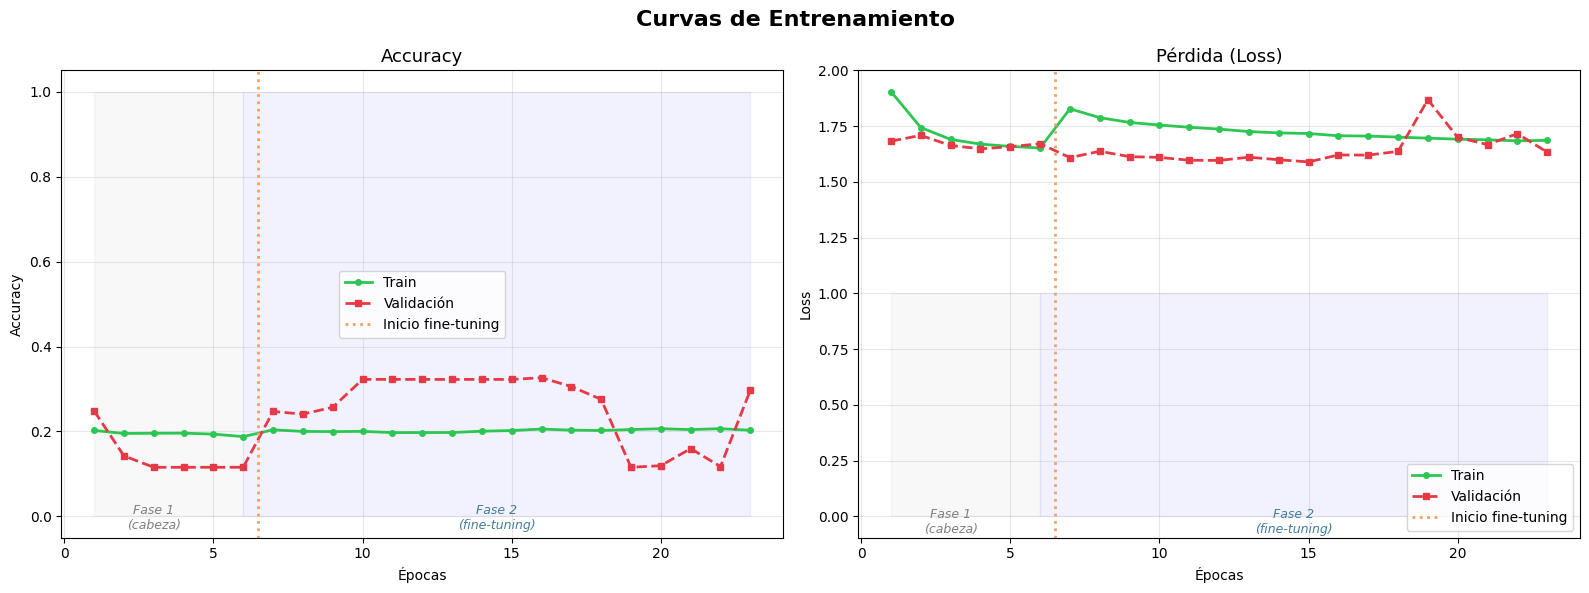


 Mejor val_accuracy: 0.3266 (época 16)


In [16]:
def plot_training_curves(h1, h2):
    # Concatenar historiales de ambas fases
    acc  = h1.history['accuracy']  + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss']      + h2.history['loss']
    val_loss = h1.history['val_loss']    + h2.history['val_loss']
    sep = len(h1.history['accuracy'])  # punto de separación entre fases

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Curvas de Entrenamiento', fontsize=16, fontweight='bold')

    epochs_range = range(1, len(acc) + 1)

    for ax, train_data, val_data, title, ylabel in [
        (axes[0], acc, val_acc, 'Accuracy', 'Accuracy'),
        (axes[1], loss, val_loss, 'Pérdida (Loss)', 'Loss'),
    ]:
        ax.plot(epochs_range, train_data, 'o-', color='#2DC653', label='Train', linewidth=2, markersize=4)
        ax.plot(epochs_range, val_data,   's--', color='#E63946', label='Validación', linewidth=2, markersize=4)
        ax.axvline(x=sep + 0.5, color='#F4A261', linestyle=':', linewidth=2, label='Inicio fine-tuning')
        ax.fill_between(range(1, sep + 1), 0, 1, alpha=0.05, color='gray')
        ax.fill_between(range(sep, len(acc) + 1), 0, 1, alpha=0.05, color='blue')
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('Épocas')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.text(sep / 2, ax.get_ylim()[0] + 0.02, 'Fase 1\n(cabeza)', ha='center',
                fontsize=9, color='gray', style='italic')
        ax.text(sep + (len(acc) - sep) / 2, ax.get_ylim()[0] + 0.02, 'Fase 2\n(fine-tuning)',
                ha='center', fontsize=9, color='#457B9D', style='italic')

    plt.tight_layout()
    plt.savefig('/content/training_curves.png', dpi=130, bbox_inches='tight')
    plt.show()
    print(f'\n Mejor val_accuracy: {max(val_acc):.4f} (época {val_acc.index(max(val_acc))+1})')

plot_training_curves(history1, history2)

##  Celda 11 — Evaluación Completa del Modelo

 Mejor modelo cargado desde: /content/emotion_model_best.h5
113/113 ━━━━━━━━━━━━━━━━━━━━ 18s 98ms/step

────────────────────────────────────────────────────────────
 REPORTE DE CLASIFICACIÓN
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

   confusion       0.00      0.00      0.00      1024
desesperanza       0.33      0.96      0.49      2316
   felicidad       0.00      0.00      0.00      1774
 neutralidad       0.00      0.00      0.00      1233
     orgullo       0.29      0.13      0.18       831

    accuracy                           0.33      7178
   macro avg       0.12      0.22      0.13      7178
weighted avg       0.14      0.33      0.18      7178



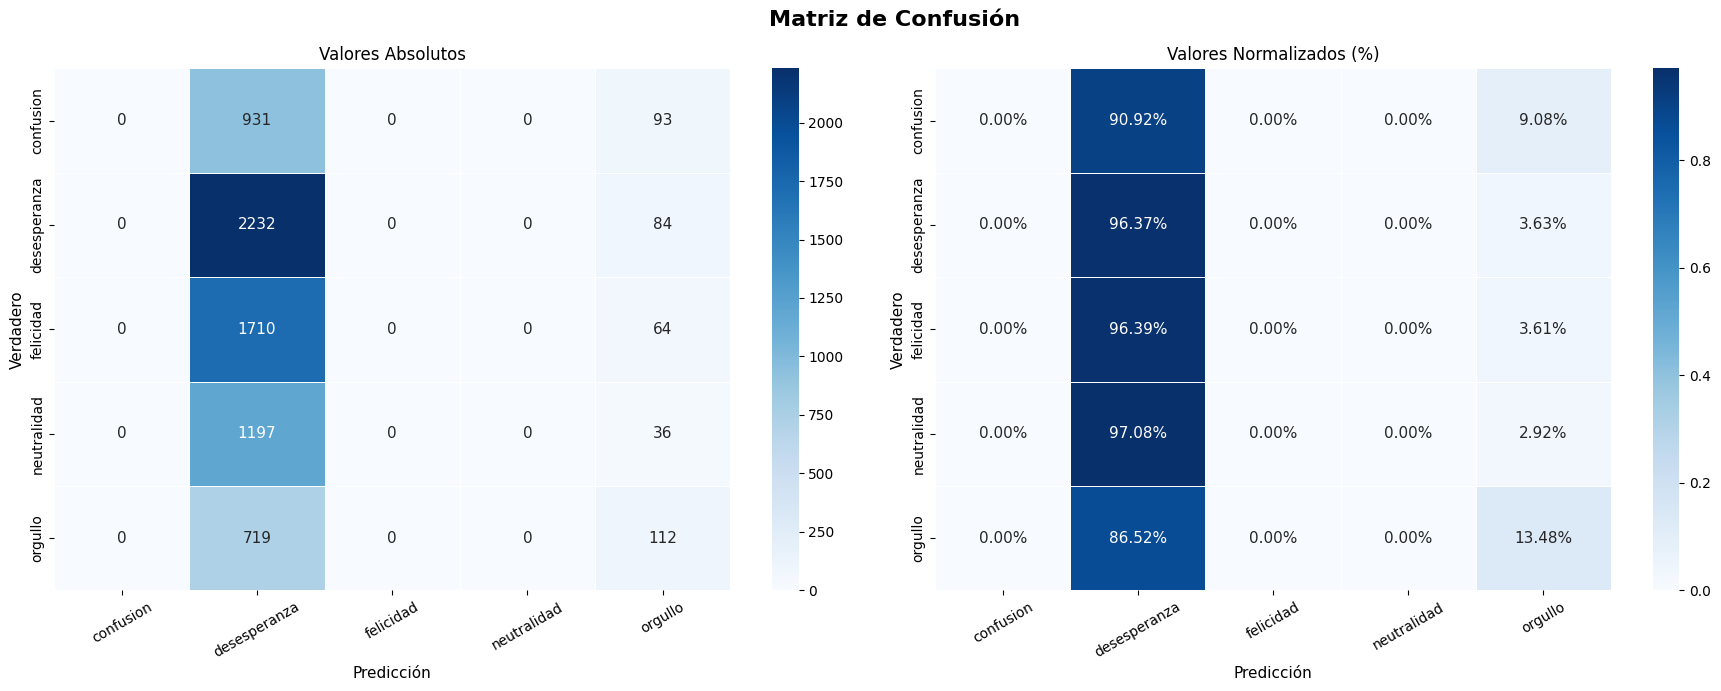


 MÉTRICAS FINALES EN TEST SET
   Accuracy : 0.3266 (32.66%)
   AUC      : 0.6110
   Loss     : 1.6208


In [17]:
# Cargar el mejor modelo guardado
best_model = keras.models.load_model(MODEL_PATH)
print(f' Mejor modelo cargado desde: {MODEL_PATH}')

# Predicciones en test set
test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# Reporte de clasificación
print('\n' + '─'*60)
print(' REPORTE DE CLASIFICACIÓN')
print('─'*60)
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Matriz de Confusión', fontsize=16, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], cm, 'Valores Absolutos', 'd'),
    (axes[1], cm_norm, 'Valores Normalizados (%)', '.2%'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, ax=ax,
        xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
        cmap='Blues', linewidths=0.5, linecolor='white',
        annot_kws={'size': 11}
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Verdadero', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

# Métricas globales
loss, acc, auc = best_model.evaluate(test_gen, verbose=0)
print(f'\n MÉTRICAS FINALES EN TEST SET')
print(f'   Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'   AUC      : {auc:.4f}')
print(f'   Loss     : {loss:.4f}')

##  Celda 12 — Análisis de Casos Difíciles (Errores del Modelo)

In [18]:
# Mostrar imágenes donde el modelo falló con alta confianza
test_gen.reset()
all_imgs, all_true, all_pred, all_conf = [], [], [], []

for batch_imgs, batch_labels in test_gen:
    preds = best_model.predict(batch_imgs, verbose=0)
    all_imgs.extend(batch_imgs)
    all_true.extend(np.argmax(batch_labels, axis=1))
    all_pred.extend(np.argmax(preds, axis=1))
    all_conf.extend(np.max(preds, axis=1))
    if len(all_imgs) >= len(test_gen.filenames):
        break

# Errores con > 80% confianza (casos críticos)
errors = [(i, all_true[i], all_pred[i], all_conf[i])
          for i in range(len(all_true))
          if all_true[i] != all_pred[i] and all_conf[i] > 0.80]

errors.sort(key=lambda x: x[3], reverse=True)
show_errors = errors[:10]

if show_errors:
    fig, axes = plt.subplots(2, 5, figsize=(18, 8))
    fig.suptitle(f'Top {len(show_errors)} Errores con Mayor Confianza\n(predicción incorrecta con alta certeza)',
                 fontsize=14, fontweight='bold')
    for idx, (i, true, pred, conf) in enumerate(show_errors):
        ax = axes[idx // 5][idx % 5]
        ax.imshow(all_imgs[i].astype('uint8'))
        true_name = EMOTION_LABELS[true]
        pred_name = EMOTION_LABELS[pred]
        ax.set_title(
            f'Real: {true_name}\nPred: {pred_name}\nConf: {conf:.1%}',
            fontsize=9, color='white',
            bbox=dict(facecolor='#E63946', edgecolor='none', boxstyle='round,pad=0.3')
        )
        ax.axis('off')
    for idx in range(len(show_errors), 10):
        axes[idx // 5][idx % 5].axis('off')
    plt.tight_layout()
    plt.savefig('/content/hard_cases.png', dpi=110, bbox_inches='tight')
    plt.show()
else:
    print(' No hay errores con confianza > 80%. El modelo es muy preciso.')

 No hay errores con confianza > 80%. El modelo es muy preciso.


## Celda 13 — INFERENCIA: Sube Tu Propia Foto

> Sube una imagen de un rostro humano y el modelo detectará la emoción.
>
> Formatos soportados: `.jpg`, `.jpeg`, `.png`

 Sube una imagen de un rostro para analizar:


Saving Room1-40.23.png to Room1-40.23.png

 Analizando: Room1-40.23.png...


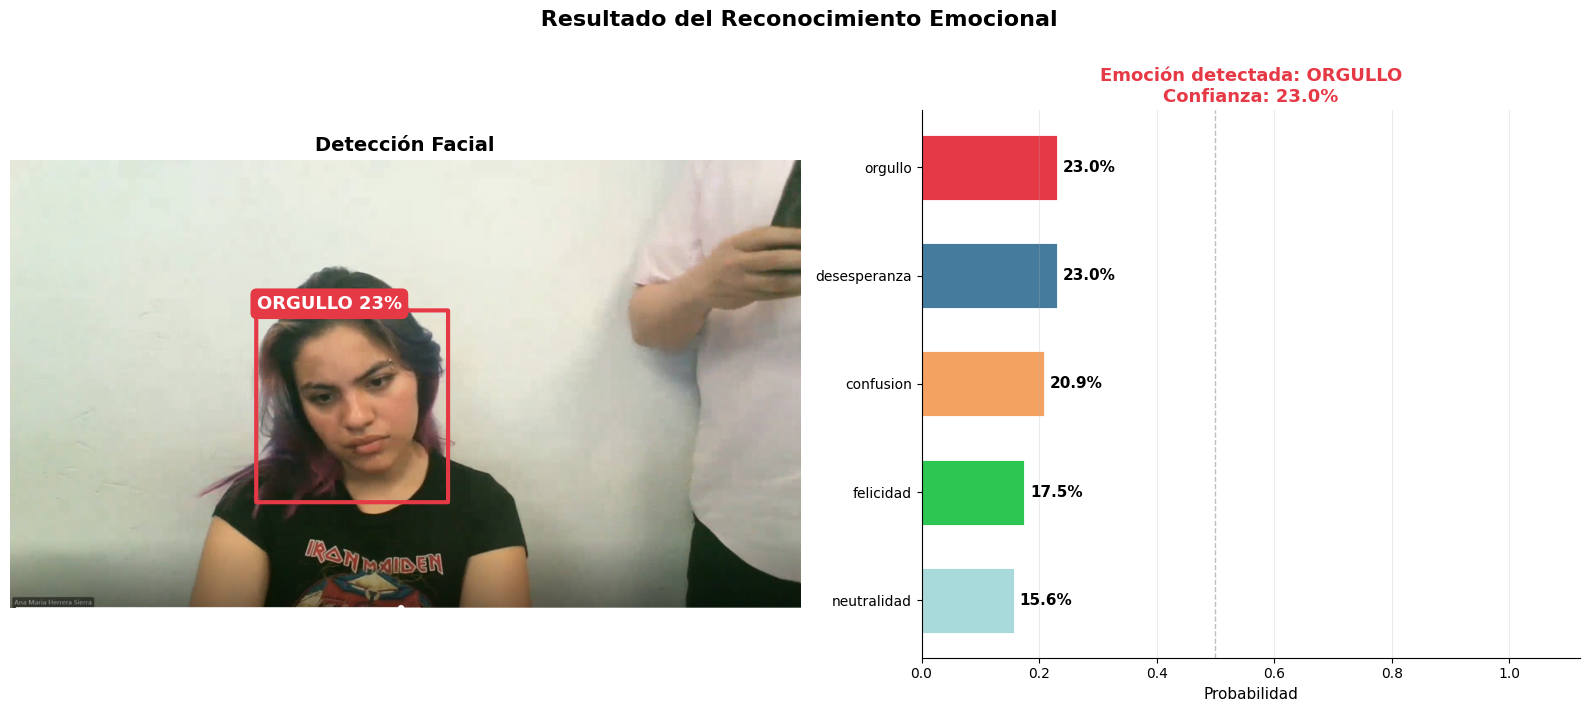


══════════════════════════════════════════════════
   EMOCIÓN PRINCIPAL : ORGULLO
  CONFIANZA         : 23.00%
══════════════════════════════════════════════════
  Todas las probabilidades:
  orgullo         doordoordoordoordoordoor       23.00%
  desesperanza    doordoordoordoordoordoor       22.98%
  confusion       doordoordoordoordoordoor       20.89%
  felicidad       doordoordoordoordoor           17.48%
  neutralidad     doordoordoordoor               15.65%
══════════════════════════════════════════════════


In [24]:
def predict_emotion(image_path: str, model: Model, show_plot: bool = True) -> dict:
    """
    Predice la emoción en una imagen con detección facial y visualización.

    Returns: dict con 'emotion', 'confidence', y 'all_probs'
    """
    # Cargar imagen
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f' No se pudo cargar la imagen: {image_path}')
        return {}

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_display = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # para matplotlib

    # Detectar rostros
    faces = face_cascade.detectMultiScale(
        img_gray, scaleFactor=1.05, minNeighbors=3, minSize=(30, 30)
    )

    results = []

    if len(faces) == 0:
        print('  No se detectó rostro — usando imagen completa para predicción')
        faces = [(0, 0, img_gray.shape[1], img_gray.shape[0])]

    for (x, y, w, h) in faces:
        # Recortar rostro
        margin = int(0.12 * min(w, h))
        x1, y1 = max(0, x - margin), max(0, y - margin)
        x2, y2 = min(img_gray.shape[1], x + w + margin), min(img_gray.shape[0], y + h + margin)
        face_crop = img_gray[y1:y2, x1:x2]

        # Preprocesar
        face_processed = preprocess_face(face_crop)
        face_input = np.expand_dims(face_processed, axis=0).astype('float32')

        # Predicción con TTA (Test-Time Augmentation): horizontal flip
        pred1 = model.predict(face_input, verbose=0)[0]
        pred2 = model.predict(face_input[:, :, ::-1, :], verbose=0)[0]  # flip horizontal
        probs = (pred1 + pred2) / 2.0  # promedio ensemble

        top_idx  = np.argmax(probs)
        emotion  = EMOTION_LABELS[top_idx]
        confidence = probs[top_idx]
        results.append({
            'bbox': (x1, y1, x2, y2),
            'emotion': emotion,
            'confidence': confidence,
            'all_probs': {EMOTION_LABELS[i]: float(probs[i]) for i in range(len(EMOTION_LABELS))}
        })

    if show_plot and results:
        fig = plt.figure(figsize=(16, 7))
        gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

        # ── Panel izquierdo: imagen con anotaciones ──
        ax_img = fig.add_subplot(gs[0])
        img_annotated = img_display.copy()

        for res in results:
            x1, y1, x2, y2 = res['bbox']
            emo   = res['emotion']
            conf  = res['confidence']
            color_hex = EMOTION_COLORS[emo]
            color_rgb = tuple(int(color_hex.lstrip('#')[i:i+2], 16) / 255 for i in (0, 2, 4))

            rect = mpatches.FancyBboxPatch(
                (x1, y1), x2 - x1, y2 - y1,
                boxstyle='round,pad=2',
                linewidth=3, edgecolor=color_rgb, facecolor='none'
            )
            ax_img.add_patch(rect)
            ax_img.text(
                x1, y1 - 8,
                f'{emo.upper()} {conf:.0%}',
                color='white', fontsize=13, fontweight='bold',
                bbox=dict(facecolor=color_rgb, edgecolor='none', boxstyle='round,pad=0.35')
            )

        ax_img.imshow(img_annotated)
        ax_img.set_title('Detección Facial', fontsize=14, fontweight='bold')
        ax_img.axis('off')

        # ── Panel derecho: probabilidades por emoción ──
        ax_bar = fig.add_subplot(gs[1])
        main_result = sorted(results, key=lambda r: r['confidence'], reverse=True)[0]
        probs_sorted = sorted(main_result['all_probs'].items(), key=lambda x: x[1])
        labels = [p[0] for p in probs_sorted]
        values = [p[1] for p in probs_sorted]
        bar_colors = [EMOTION_COLORS[l] for l in labels]

        bars = ax_bar.barh(labels, values, color=bar_colors, edgecolor='white',
                           linewidth=0.6, height=0.6)
        ax_bar.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)

        for bar, val in zip(bars, values):
            ax_bar.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                        f'{val:.1%}', va='center', fontsize=11, fontweight='bold')

        top_emo = main_result['emotion']
        ax_bar.set_title(
            f'Emoción detectada: {top_emo.upper()}\nConfianza: {main_result["confidence"]:.1%}',
            fontsize=13, fontweight='bold',
            color=EMOTION_COLORS[top_emo]
        )
        ax_bar.set_xlabel('Probabilidad', fontsize=11)
        ax_bar.set_xlim(0, 1.12)
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.grid(axis='x', alpha=0.25)

        plt.suptitle(' Resultado del Reconocimiento Emocional', fontsize=16,
                     fontweight='bold', y=1.01)
        plt.tight_layout()
        plt.savefig('/content/inference_result.png', dpi=130, bbox_inches='tight')
        plt.show()

        print('\n' + '═'*50)
        print(f'   EMOCIÓN PRINCIPAL : {top_emo.upper()}')
        print(f'  CONFIANZA         : {main_result["confidence"]:.2%}')
        print('═'*50)
        print('  Todas las probabilidades:')
        for emo, prob in sorted(main_result['all_probs'].items(), key=lambda x: -x[1]):
            bar = 'door' * int(prob * 30)
            print(f'  {emo:15s} {bar:<30s} {prob:.2%}')
        print('═'*50)

    return results


# ── Subir y predecir ────────────────────────────────────────
print(' Sube una imagen de un rostro para analizar:')
uploaded_img = files.upload()

if uploaded_img:
    img_name = list(uploaded_img.keys())[0]
    img_path = f'/content/{img_name}'
    with open(img_path, 'wb') as f:
        f.write(uploaded_img[img_name])
    print(f'\n Analizando: {img_name}...')
    results = predict_emotion(img_path, best_model)
else:
    print(' No se subió ninguna imagen.')